In [ ]:
using QuantumInputOutput
using SecondQuantizedAlgebra
using QuantumOptics
using LinearAlgebra
using PyPlot

In [2]:
γR1, γR2, γL1, γL2, Δ1, Δ2, ϕ, Ein = rnumbers("γ^{(1)}_R γ^{(2)}_R γ^{(1)}_L γ^{(2)}_L Δ_1 Δ_2 ϕ E_{in}")

ha1 = NLevelSpace(:a1,2)
ha2 = NLevelSpace(:a2,2)
h = ha1 ⊗ ha2

σ1(i,j) = Transition(h,:σ_1,i,j,1)
σ2(i,j) = Transition(h,:σ_2,i,j,2);

In [3]:
G_d = SLH(1, Ein, 0)
G_ϕ = SLH(exp(1im*ϕ), 0, 0)
G_a1_R = SLH(1, √(γR1)*σ1(1,2), -Δ1*σ1(2,2))
G_a2_R = SLH(1, √(γR2)*σ2(1,2), -Δ2*σ2(2,2))
#
G_a1_L = SLH(1, √(γL1)*σ1(1,2), 0)
G_a2_L = SLH(1, √(γL2)*σ2(1,2), 0);

In [4]:
G_R = cascade([G_d, G_a1_R, G_ϕ, G_a2_R]...)
G_L = cascade([G_a2_L, G_ϕ, G_a1_L]...)

G_t = G_R ⊞ G_L ;

In [5]:
S = get_scattering(G_t)
L = get_lindblad(G_t)
H = get_hamiltonian(G_t)

((0.0 - 0.5im)*exp((0 + 1im)*ϕ)*sqrt(var"γ^{(1)}_R")*sqrt(var"γ^{(2)}_R")*(σ_112*σ_221)+-Δ_1*(σ_122)+-Δ_2*(σ_222)+(0.0 - 0.5im)*var"E_{in}"*exp((0 + 1im)*ϕ)*sqrt(var"γ^{(2)}_R")*(σ_221)+(0.0 + 0.5im)*var"E_{in}"*exp((0 - 1im)*ϕ)*sqrt(var"γ^{(2)}_R")*(σ_212)+(0.0 + 0.5im)*var"E_{in}"*sqrt(var"γ^{(1)}_R")*(σ_112)+(0.0 + 0.5im)*exp((0 - 1im)*ϕ)*sqrt(var"γ^{(1)}_R")*sqrt(var"γ^{(2)}_R")*(σ_121*σ_212)+(0.0 - 0.5im)*var"E_{in}"*sqrt(var"γ^{(1)}_R")*(σ_121)+(0.0 + 0.5im)*exp((0 - 1im)*ϕ)*sqrt(var"γ^{(2)}_L")*sqrt(var"γ^{(1)}_L")*(σ_112*σ_221)+(0.0 - 0.5im)*sqrt(var"γ^{(2)}_L")*exp((0 + 1im)*ϕ)*sqrt(var"γ^{(1)}_L")*(σ_121*σ_212))

In [6]:
L[1]

(exp((0 + 1im)*ϕ)*sqrt(var"γ^{(1)}_R")*(σ_112)+var"E_{in}"*exp((0 + 1im)*ϕ)+sqrt(var"γ^{(2)}_R")*(σ_212))

In [7]:
L[2]

(sqrt(var"γ^{(1)}_L")*(σ_112)+sqrt(var"γ^{(2)}_L")*exp((0 + 1im)*ϕ)*(σ_212))

In [8]:
# numerical parameters and functions
γ_ = 1.0
γR1_ = γL1_ = γR2_ = γL2_ = γ_/2
Δ1_ = Δ2_ = 0 #-γ_ #0.0 #TODO
ϕ_ = π/2

p_sym = [γR1,  γR2,  γL1,  γL2,  Δ1,  Δ2,  ϕ]
p_num = [γR1_, γR2_, γL1_, γL2_, Δ1_, Δ2_, ϕ_]

σp = 10/γ_ # pulse width 
Tp = 4σp   # pulse peak 
Tend = 3Tp
α0 = √(0.04) # √ of total photon number
Ω0_1 = α0*2*√(γR1_)/(π^(1/4)*√(σp)) # σp ... pulse width, 
Ω1(t) = Ω0_1/2*exp( -(t-Tp)^2 / (2*σp^2) )
Ein_t(t) = Ω1(t)/√(γR1_)

dict_p = Dict(p_sym .=> p_num)
dict_p_t = Dict( [Ein, conj(Ein)] .=> [Ein_t, Ein_t] );

In [9]:
# numeric bases
ba1 = NLevelBasis(2)
ba2 = NLevelBasis(2)
b = ba1 ⊗ ba2

[NLevel(N=2) ⊗ NLevel(N=2)]

In [10]:
# translate to numeric Hamiltonian and Lindblad
H_QO = translate(H, b; parameter=dict_p, time_dep_param=dict_p_t)
L_QO_1 = translate(L[1], b; parameter=dict_p, time_dep_param=dict_p_t)
L_QO_2 = translate(L[2], b; parameter=dict_p, time_dep_param=dict_p_t)
function input_output(t,ρ)
    H = H_QO(t)
    J = [L_QO_1(t), L_QO_2(t)]
    return H, J, dagger.(J)
end;

In [11]:
# time evolution
T = [0:0.001:1;]*Tend
ψ0 = nlevelstate(ba1,1) ⊗ nlevelstate(ba2,1)
t_, ρt = timeevolution.master_dynamic(T, ψ0, input_output; abstol, reltol);

In [12]:
L_QO_1_dag(t) = dagger(L_QO_1(t))
L_QO_2_dag(t) = dagger(L_QO_2(t))

l_t = length(t_)
n_trans = zeros(l_t)
n_ref = zeros(l_t)

for it=1:l_t
    n_trans[it] = abs(expect( L_QO_1_dag(t_[it])* L_QO_1(t_[it]), ρt[it]))
    n_ref[it] = abs(expect( L_QO_2_dag(t_[it])* L_QO_2(t_[it]), ρt[it]))
end

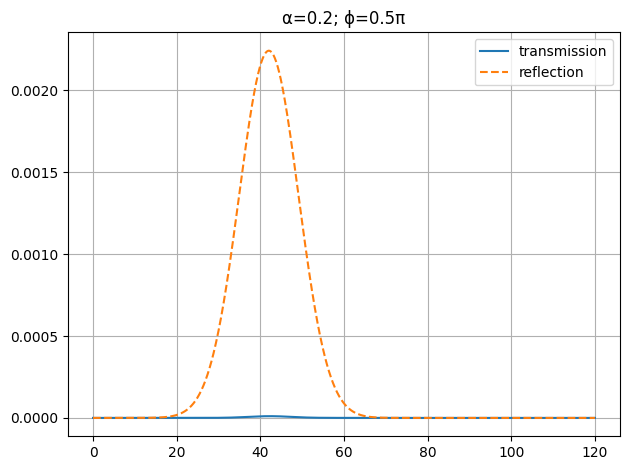

In [13]:
cd(@__DIR__)
close("time evolution")
figure("time evolution")
title("α=$(α0); ϕ=$(ϕ_/π)π")
plot(t_, n_trans, label="transmission")
plot(t_, n_ref, ls="--", label="reflection")
tight_layout()
legend()
grid(true)
display(gcf())
# savefig("test_phi=$(ϕ_/π)_QIO_coh.png")

In [14]:
n_total = round(sum(n_trans)*(T[2] - T[1]) + sum(n_ref)*(T[2] - T[1]); digits=7)

0.0400001

In [15]:
@show maximum(n_trans)
@show maximum(n_ref);

maximum(n_trans) = 1.0639498412872718e-5
maximum(n_ref) = 0.0022429957303851276


In [16]:
σ1_QO(i,j) = to_numeric(σ1(i,j),b)
σ2_QO(i,j) = to_numeric(σ2(i,j),b)

σ1_22_t = real.(expect(σ1_QO(2,2), ρt))
σ2_22_t = real.(expect(σ2_QO(2,2), ρt));

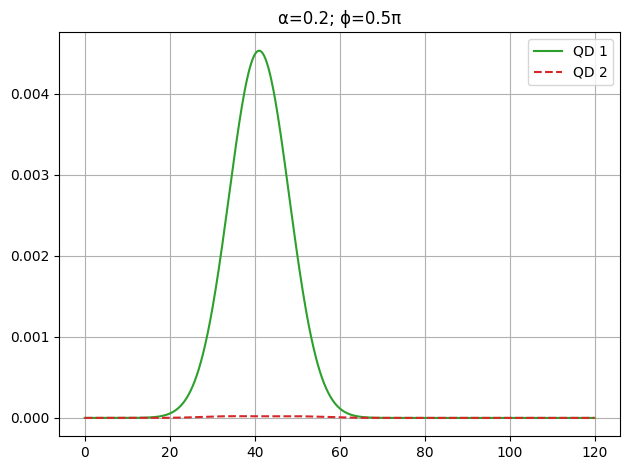

In [17]:
cd(@__DIR__)
close("time evolution popu")
figure("time evolution popu")
title("α=$(α0); ϕ=$(ϕ_/π)π")
plot(t_, σ1_22_t, label="QD 1", color="C2")
plot(t_, σ2_22_t, ls="--", label="QD 2", color="C3")
tight_layout()
legend()
grid(true)
display(gcf())